# Check states
Created 02/04/2026

Objectives:
* Check states saved [here](../../save_states/z4_z2_trs_cluster_chain_100_site_dmrg.ipynb).

# Package imports

In [1]:
import sys
sys.path.append("../..")

In [2]:
from functools import reduce
from itertools import combinations

In [3]:
import h5py
from tenpy.tools import hdf5_io
import tenpy
import tenpy.linalg.np_conserved as npc

import os

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
import quimb as qu
import quimb.tensor as qtn

/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:54: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:36: UserWarning: Couldn't import `kahypar` - skipping from default hyper optimizer and using basic `labels` method instead.
  warnings.warn(
/home/kcooney/Desktop/repos/spt_numerical_classificiation/code/num_spt_venv_p11/lib/python3.11/site-packages/cotengra/hyperoptimizers/hyper.py:73: UserWarning: Couldn't find `optuna`, `cmaes`, or `nevergrad` so will use completely random sampling in place of hyper-optimization.
  warnings.warn(


# Load data

In [6]:
DATA_DIR = r"../../data/4_2_trs_cluster_chain_100_unit_cells"

In [8]:
loaded_data = list()

for local_file_name in os.listdir(DATA_DIR):
    if local_file_name[-3:] == '.h5':
        f_name = r"{}/{}".format(DATA_DIR, local_file_name, ignore_unknown=False)
        with h5py.File(f_name, 'r') as f:
            data = hdf5_io.load_from_hdf5(f)
            loaded_data.append(data)

In [10]:
loaded_data[0]

{'energy': -153.42253188329676,
 'paramters': {'interpolation': 0.26},
 'wavefunction': <tenpy.networks.mps.MPS at 0x7f9ca74f0fd0>}

In [12]:
interpolation_values = sorted(list(d['paramters']['interpolation'] for d in loaded_data))

In [13]:
def get_quimb_mps(tenpy_mps):
    psi_arrays = list()
    psi_arrays.append(tenpy_mps.get_B(0, 'Th')[0, ...].to_ndarray())
    for i in range(1, tenpy_mps.L-1):
        psi_arrays.append(tenpy_mps.get_B(i).to_ndarray())
    psi_arrays.append(tenpy_mps.get_B(tenpy_mps.L-1)[..., 0].to_ndarray())
    
    out = (
        qtn
        .tensor_1d
        .MatrixProductState(psi_arrays, shape='lpr')
    )

    return out

In [32]:
psi_dict = dict()

for t in interpolation_values:
    psi = next(
        d['wavefunction']
        for d in loaded_data
        if d['paramters']['interpolation'] == t
    )

    rounded_t = round(t, 2)
    #psi_dict[rounded_t] = get_quimb_mps(psi)
    psi_dict[rounded_t] = psi

# Definitions

In [20]:
np_I = np.array([[1,0],[0,1]])
np_X = np.array([[0,1],[1,0]])
np_Y = np.array([[0,-1j],[1j,0]])
np_Z = np.array([[1,0],[0,-1]])

In [21]:
symmetry_actions = [
    [np_I, np_I],
    [np_I, np_X],
    [np_X, np_I],
    [np_X, np_X]
]

In [22]:
symmetry_labels = [
    'II',
    'IX',
    'XI',
    'XX'
]

# Analysis
## Energies

In [24]:
loaded_data[0]

{'energy': -153.42253188329676,
 'paramters': {'interpolation': 0.26},
 'wavefunction': <tenpy.networks.mps.MPS at 0x7f9ca74f0fd0>}

In [25]:
values = list()
energies = list()

for d in loaded_data:
    values.append(d['paramters']['interpolation'])
    energies.append(d['energy'])

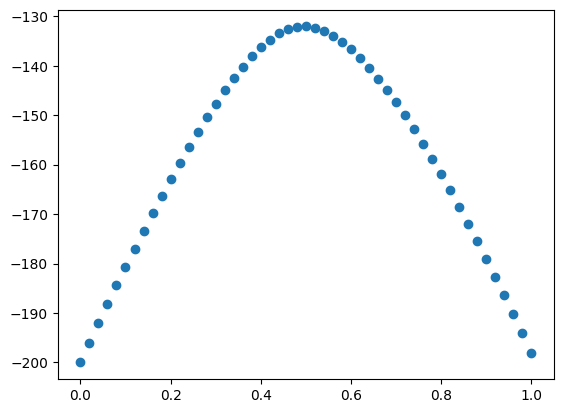

In [27]:
plt.plot(values, energies, 'o')

Critical point at $t=0.5$...?

## String order parameters

Try $Z_2 X_4 I \ldots X_4 Z_2$.

In [53]:
sop_1 = ['Sz',] + (['X', 'Id']*50) +  ['X', 'Sz']

In [54]:
psi_dict[0].expectation_value_multi_sites(sop_1, 50)

array(0.)

In [55]:
sop_1_list = [
    psi.expectation_value_multi_sites(sop_1, 70)
    for psi in psi_dict.values()
]

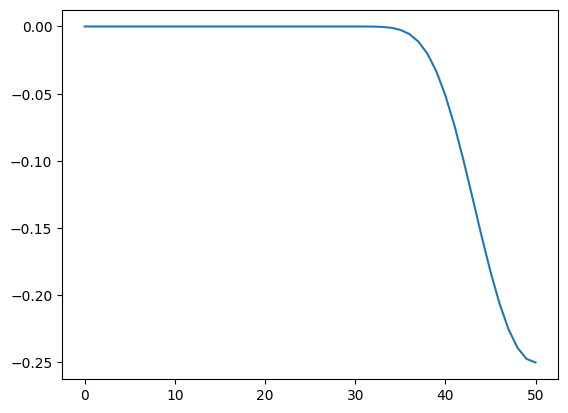

In [56]:
plt.plot(sop_1_list)

# First iteration

In [15]:
test_psi = psi_dict[0.0]

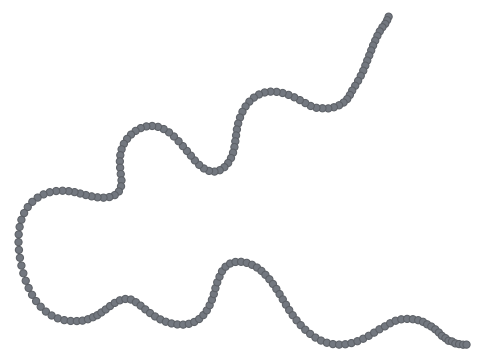

In [16]:
test_psi.draw()

In [17]:
test_psi.conj()

MatrixProductState(tensors=200, indices=399, L=200, max_bond=2)

In [18]:
num_sites = 3

In [19]:
test_rho = test_psi.partial_trace_to_mpo(
    list(range(100-num_sites, 100+num_sites))
)

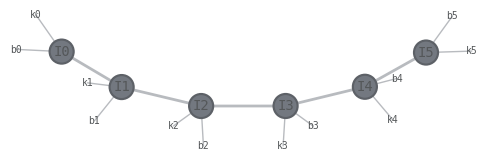

In [20]:
test_rho.draw()

In [21]:
test_rho

MatrixProductOperator(tensors=6, indices=17, L=6, max_bond=4)

In [22]:
test_rho_pt = test_rho.partial_transpose(
    list(range(100-num_sites, 100+num_sites)),
    inplace=False
)

In [23]:
test_rho_pt

MatrixProductOperator(tensors=6, indices=17, L=6, max_bond=4)

In [24]:
test_rho_2 = test_rho.copy()

In [25]:
test_rho_2.reindex(
    {f'{s}{i}': f'{s}{i}_2' for s in ['k', 'b'] for i in range(2*num_sites)},
    inplace=True
)

MatrixProductOperator(tensors=6, indices=17, L=6, max_bond=4)

In [26]:
test_rho_2

MatrixProductOperator(tensors=6, indices=17, L=6, max_bond=4)

In [27]:
test_rho.reindex(
    {f'{s}{i}': f'{s}{i}_1' for s in ['k', 'b'] for i in range(2*num_sites)},
    inplace=True
)

MatrixProductOperator(tensors=6, indices=17, L=6, max_bond=4)

In [28]:
test_rho

MatrixProductOperator(tensors=6, indices=17, L=6, max_bond=4)

In [29]:
x_gate = qtn.Tensor(data=np_X, inds=('b', 'k'))

In [30]:
x_gate

Tensor(shape=(2, 2), inds=('b', 'k'), tags=oset([]))

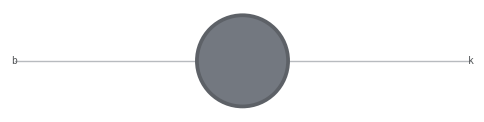

In [31]:
x_gate.draw()

In [32]:
x_gates_b = [
    x_gate.copy().reindex({'b': f'b{i}_1', 'k': f'b{i}_2'})
    for i in range(num_sites)
]

x_gates_k = [
    x_gate.copy().reindex({'b': f'k{i}_1', 'k': f'k{i}_2'})
    for i in range(num_sites)
]

In [33]:
len(x_gates_b)

3

In [34]:
x_gates_b

[Tensor(shape=(2, 2), inds=('b0_1', 'b0_2'), tags=oset([])),
 Tensor(shape=(2, 2), inds=('b1_1', 'b1_2'), tags=oset([])),
 Tensor(shape=(2, 2), inds=('b2_1', 'b2_2'), tags=oset([]))]

In [35]:
x_gates_k

[Tensor(shape=(2, 2), inds=('k0_1', 'k0_2'), tags=oset([])),
 Tensor(shape=(2, 2), inds=('k1_1', 'k1_2'), tags=oset([])),
 Tensor(shape=(2, 2), inds=('k2_1', 'k2_2'), tags=oset([]))]

In [36]:
(
    test_rho_2
    .reindex(
        {f'k{i}_2': f'b{i}_1' for i in range(num_sites, 2*num_sites)},
        inplace=True
    )
    .reindex(
        {f'b{i}_2': f'k{i}_1' for i in range(num_sites, 2*num_sites)},
        inplace=True
    )
)

MatrixProductOperator(tensors=6, indices=17, L=6, max_bond=4)

In [37]:
test_rho_2

MatrixProductOperator(tensors=6, indices=17, L=6, max_bond=4)

In [38]:
final = qtn.tensor_core.TensorNetwork(
    [
        test_rho,
        test_rho_2,
        *x_gates_b,
        *x_gates_k
    ]
)

In [39]:
final

TensorNetwork(tensors=18, indices=28)

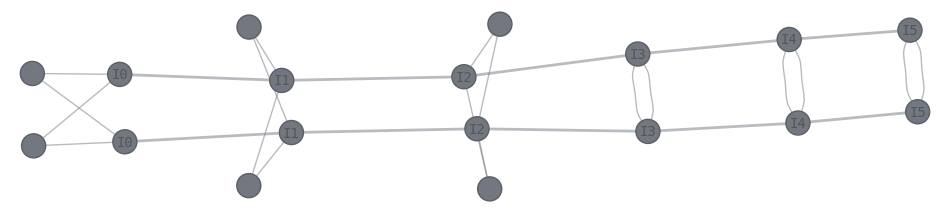

In [40]:
final.draw(show_inds=True, figsize=(12, 8))

# Run and sweep

In [41]:
x_gate = qtn.Tensor(data=np_X, inds=('b', 'k'))

In [42]:
def trs_order_parameter(psi, num_sites=20):
    rho = psi.partial_trace_to_mpo(
        list(range(100-num_sites, 100+num_sites))
    )

    rho_2 = rho.copy()

    rho.reindex(
        {f'{s}{i}': f'{s}{i}_1' for s in ['k', 'b'] for i in range(2*num_sites)},
        inplace=True
    )
    
    rho_2.reindex(
        {f'{s}{i}': f'{s}{i}_2' for s in ['k', 'b'] for i in range(2*num_sites)},
        inplace=True
    )

    x_gates_b = [
        x_gate.copy().reindex({'b': f'b{i}_1', 'k': f'b{i}_2'})
        for i in range(num_sites)
    ]
    
    x_gates_k = [
        x_gate.copy().reindex({'b': f'k{i}_1', 'k': f'k{i}_2'})
        for i in range(num_sites)
    ]

    (
        rho_2
        .reindex(
            {f'k{i}_2': f'b{i}_1' for i in range(num_sites, 2*num_sites)},
            inplace=True
        )
        .reindex(
            {f'b{i}_2': f'k{i}_1' for i in range(num_sites, 2*num_sites)},
            inplace=True
        )
    )

    final = qtn.tensor_core.TensorNetwork(
        [
            rho,
            rho_2,
            *x_gates_b,
            *x_gates_k
        ]
    )

    out = final.contract()

    return out

In [43]:
trs_order_parameters = [
    trs_order_parameter(psi) for psi in psi_dict.values()
]

In [44]:
b_strengths = list(psi_dict.keys())

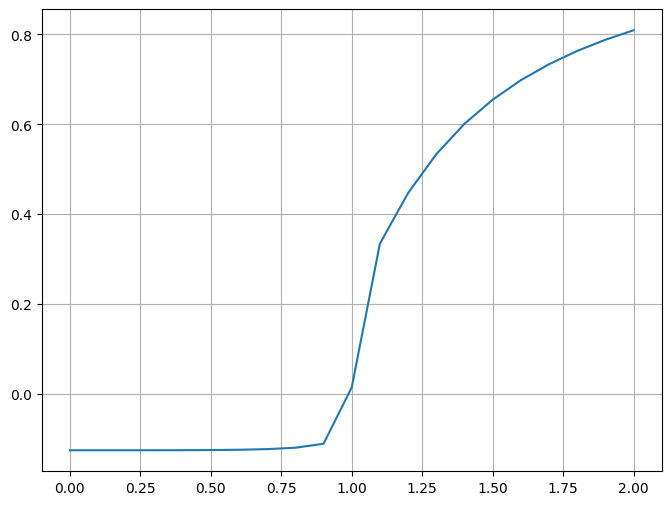

In [45]:
fig, ax = plt.subplots(figsize=(8,6))

ax.plot(b_strengths, trs_order_parameters)
ax.grid()

Compare with expected value.

In [51]:
expected_magnitudes = [
    (-1 if k < 1 else 1)*np.sum(v.schmidt_values(100)**2)**3
    for k, v in psi_dict.items()
]

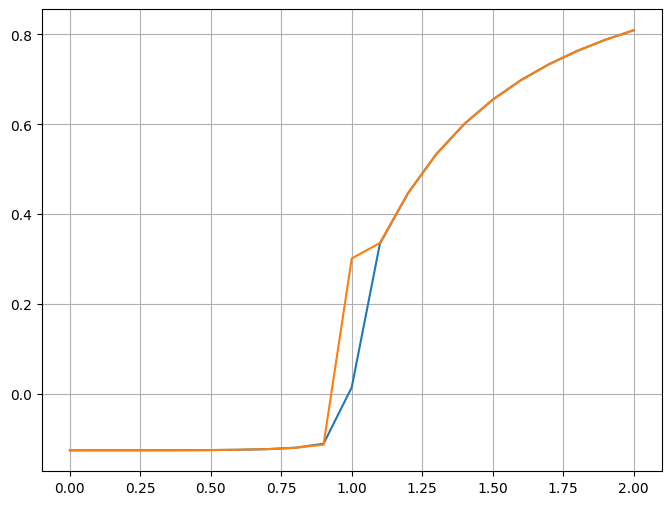

In [52]:
fig, ax = plt.subplots(figsize=(8,6))

ax.plot(b_strengths, trs_order_parameters)
ax.plot(b_strengths, expected_magnitudes)
ax.grid()

Yes, matches exactly! (Except at critical point, as expected.)

# Conclusions
That's what we expected!